In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV
from matplotlib.colors import ListedColormap
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import cross_val_score

In [4]:
spotify_tracks = pd.read_csv("dataset.csv", index_col=0)

In [6]:
spotify_tracks.head(3)

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,1,-6.746,0,0.1430,0.0322,0.000001,0.358,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,1,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,0,-9.734,1,0.0557,0.2100,0.000000,0.117,0.120,76.332,4,acoustic


In [7]:
spotify_tracks.shape

(114000, 20)

In [8]:
spotify_tracks[spotify_tracks.isnull().any(axis=1)]

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
65900,1kR4gIb7nGxHPI3D2ifs59,NaN,NaN,NaN,0,0,False,0.501,0.583,7,-9.46,0,0.0605,0.69,0.00396,0.0747,0.734,138.391,4,k-pop


Since there's only one null value i'll drop it 

In [9]:
spotify_tracks = spotify_tracks.dropna(axis=0)

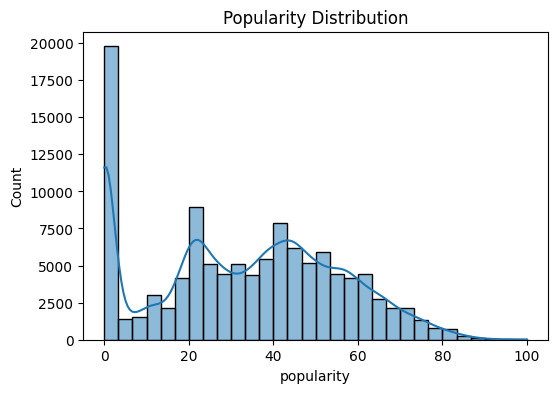

In [10]:
plt.figure(figsize=(6, 4))
sns.histplot(spotify_tracks["popularity"], bins=30, kde=True)
plt.title("Popularity Distribution")
plt.show()

##### Column Description
track_id: The Spotify ID for the track
artists: The artists' names who performed the track. If there is more than one artist, they are separated by a ;
album_name: The album name in which the track appears
track_name: Name of the track


popularity: The popularity of a track is a value between 0 and 100. The popularity is calculated by algorithm and is based. Generally speaking, songs that are being played a lot now will have a higher popularity than songs that were played a lot in the past. Duplicate tracks (e.g. the same track from a single and an album) are rated independently. Artist and album popularity is derived mathematically from track popularity.

duration_ms: The track length in milliseconds
explicit: Whether or not the track has explicit lyrics (true = yes it does; false = no it does not OR unknown)

danceability: Danceability describes how suitable a track is for dancing based on a combination of musical elements including tempo, rhythm stability, beat strength, and overall regularity. A value of 0.0 is least danceable and 1.0 is most danceable

energy: Energy is a measure from 0.0 to 1.0 and represents a perceptual measure of intensity and activity. Typically, energetic tracks feel fast, loud, and noisy.

key: The key the track is in. Integers map to pitches using standard Pitch Class notation. E.g. 0 = C, 1 = C♯/D♭, 2 = D, and so on. If no key was detected, the value is -1

loudness: The overall loudness of a track in decibels (dB)

mode: Mode indicates the modality (major or minor) of a track, the type of scale from which its melodic content is derived. Major is represented by 1 and minor is 0

speechiness: Speechiness detects the presence of spoken words in a track. The more exclusively speech-like the recording (e.g. talk show, audio book, poetry), the closer to 1.0 the attribute value. Values above 0.66 describe tracks that are probably made entirely of spoken words. Values between 0.33 and 0.66 describe tracks that may contain both music and speech, either in sections or layered, including such cases as rap music. Values below 0.33 most likely represent music and other non-speech-like tracks

acousticness: A confidence measure from 0.0 to 1.0 of whether the track is acoustic. 1.0 represents high confidence the track is acoustic

instrumentalness: Predicts whether a track contains no vocals. Rap or spoken word tracks are clearly "vocal". The closer the instrumentalness value is to 1.0, the greater likelihood the track contains no vocal content

liveness: Detects the presence of an audience in the recording. Higher liveness values represent an increased probability that the track was performed live. A value above 0.8 provides strong likelihood that the track is live

valence: A measure from 0.0 to 1.0 describing the musical positiveness conveyed by a track. Tracks with high valence sound more positive (e.g. happy, cheerful, euphoric), while tracks with low valence sound more negative (e.g. sad, depressed, angry)

tempo: The overall estimated tempo of a track in beats per minute (BPM). In musical terminology, tempo is the speed or pace of a given piece and derives directly from the average beat duration

time_signature: An estimated time signature. The time signature (meter) is a notational convention to specify how many beats are in each bar (or measure). The time signature ranges from 3 to 7 indicating time signatures of 3/4, to 7/4.

track_genre: The genre in which the track belongs

In [11]:
spotify_tracks["track_genre"].unique()

array(['acoustic', 'afrobeat', 'alt-rock', 'alternative', 'ambient',
       'anime', 'black-metal', 'bluegrass', 'blues', 'brazil',
       'breakbeat', 'british', 'cantopop', 'chicago-house', 'children',
       'chill', 'classical', 'club', 'comedy', 'country', 'dance',
       'dancehall', 'death-metal', 'deep-house', 'detroit-techno',
       'disco', 'disney', 'drum-and-bass', 'dub', 'dubstep', 'edm',
       'electro', 'electronic', 'emo', 'folk', 'forro', 'french', 'funk',
       'garage', 'german', 'gospel', 'goth', 'grindcore', 'groove',
       'grunge', 'guitar', 'happy', 'hard-rock', 'hardcore', 'hardstyle',
       'heavy-metal', 'hip-hop', 'honky-tonk', 'house', 'idm', 'indian',
       'indie-pop', 'indie', 'industrial', 'iranian', 'j-dance', 'j-idol',
       'j-pop', 'j-rock', 'jazz', 'k-pop', 'kids', 'latin', 'latino',
       'malay', 'mandopop', 'metal', 'metalcore', 'minimal-techno', 'mpb',
       'new-age', 'opera', 'pagode', 'party', 'piano', 'pop-film', 'pop',
       'pow

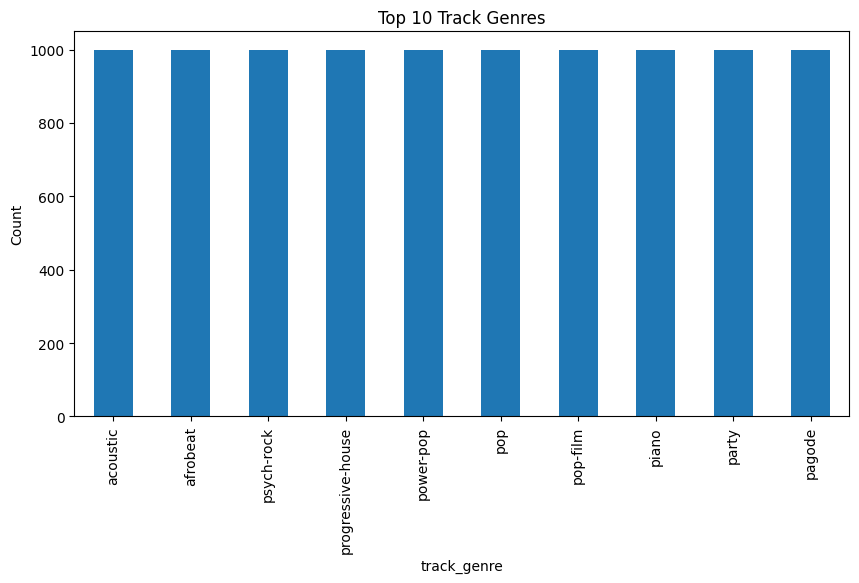

In [12]:
plt.figure(figsize=(10, 5))
spotify_tracks["track_genre"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Track Genres")
plt.ylabel("Count")
plt.show()

In [13]:
spotify_tracks[spotify_tracks.duplicated()]

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
1925,0CDucx9lKxuCZplLXUz0iX,Buena Onda Reggae Club,Disco 2,Song for Rollins,16,219346,False,0.841,0.577,0,-7.544,1,0.0438,0.238000,0.860000,0.0571,0.843,90.522,4,afrobeat
2155,2aibwv5hGXSgw7Yru8IYTO,Red Hot Chili Peppers,Stadium Arcadium,Snow (Hey Oh),80,334666,False,0.427,0.900,11,-3.674,1,0.0499,0.116000,0.000017,0.1190,0.599,104.655,4,alt-rock
3738,7mULVp0DJrI2Nd6GesLvxn,Joy Division,Timeless Rock Hits,Love Will Tear Us Apart,0,204621,False,0.524,0.902,2,-8.662,1,0.0368,0.000989,0.695000,0.1370,0.907,146.833,4,alternative
4648,6d3RIvHfVkoOtW1WHXmbX3,Little Symphony,Serenity,Margot,27,45714,False,0.269,0.142,0,-23.695,1,0.0509,0.866000,0.904000,0.1140,0.321,67.872,3,ambient
5769,481beimUiUnMUzSbOAFcUT,SUPER BEAVER,突破口 / 自慢になりたい,突破口,54,255080,False,0.472,0.994,8,-1.786,1,0.1140,0.025900,0.000000,0.0535,0.262,103.512,4,anime
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111246,0sSjIvTvd6fUSZZ5rnTPDW,Everything But The Girl,Eden (Deluxe Edition),Another Bridge - 2012 Remaster,26,132826,False,0.480,0.853,0,-6.276,1,0.0734,0.030600,0.000001,0.3200,0.775,85.181,4,trip-hop
111362,2zg3iJW4fK7KZgHOvJU67z,Faithless,Faithless 2.0,Tarantula,21,398152,False,0.622,0.816,6,-11.095,0,0.0483,0.009590,0.578000,0.0991,0.427,136.007,4,trip-hop
111980,46FPub2Fewe7XrgM0smTYI,Morcheeba,Parts of the Process,Undress Me Now,17,203773,False,0.576,0.352,7,-10.773,0,0.0268,0.700000,0.270000,0.1600,0.360,95.484,4,trip-hop
112968,6qVA1MqDrDKfk9144bhoKp,Acil Servis,Küçük Adam,Bebek,38,319933,False,0.486,0.485,5,-12.391,0,0.0331,0.004460,0.000017,0.3690,0.353,120.095,4,turkish


In [14]:
spotify_tracks["artists"].value_counts()

artists
The Beatles                                                                 279
George Jones                                                                271
Stevie Wonder                                                               236
Linkin Park                                                                 224
Ella Fitzgerald                                                             222
                                                                           ... 
Automatic Tasty                                                               1
o9                                                                            1
Pyotr Ilyich Tchaikovsky;National Philharmonic Orchestra;Richard Bonynge      1
tstewart;Ólafur Arnalds                                                       1
Jesus Culture                                                                 1
Name: count, Length: 31437, dtype: int64

In [15]:
spotify_tracks.describe().style.background_gradient(cmap="Accent")

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000
mean,33.238827,228031.153387,0.566801,0.641383,5.309126,-8.258950,0.637558,0.084652,0.314907,0.156051,0.213554,0.474066,122.147695,3.904034
std,22.304959,107296.057716,0.173543,0.251530,3.559999,5.029357,0.480708,0.105733,0.332522,0.309556,0.190378,0.259261,29.978290,0.432623
min,0.000000,8586.000000,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,174066.000000,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218500,4.000000
50%,35.000000,212906.000000,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,261506.000000,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.597500,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5237295.000000,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [16]:
spotify_tracks.info()

<class 'pandas.core.frame.DataFrame'>
Index: 113999 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          113999 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        113999 non-null  int64  
 5   duration_ms       113999 non-null  int64  
 6   explicit          113999 non-null  bool   
 7   danceability      113999 non-null  float64
 8   energy            113999 non-null  float64
 9   key               113999 non-null  int64  
 10  loudness          113999 non-null  float64
 11  mode              113999 non-null  int64  
 12  speechiness       113999 non-null  float64
 13  acousticness      113999 non-null  float64
 14  instrumentalness  113999 non-null  float64
 15  liveness          113999 non-null  float64
 16  valence           113999 

In [17]:
spotify_tracks["explicit"].value_counts()

explicit
False    104252
True       9747
Name: count, dtype: int64

In [18]:
spotify_tracks["explicit"] = spotify_tracks["explicit"].astype(int)

In [19]:
# spotify_tracks.head(2)

In [20]:
spotify_tracks.info()

<class 'pandas.core.frame.DataFrame'>
Index: 113999 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          113999 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        113999 non-null  int64  
 5   duration_ms       113999 non-null  int64  
 6   explicit          113999 non-null  int32  
 7   danceability      113999 non-null  float64
 8   energy            113999 non-null  float64
 9   key               113999 non-null  int64  
 10  loudness          113999 non-null  float64
 11  mode              113999 non-null  int64  
 12  speechiness       113999 non-null  float64
 13  acousticness      113999 non-null  float64
 14  instrumentalness  113999 non-null  float64
 15  liveness          113999 non-null  float64
 16  valence           113999 

In [21]:
corr = spotify_tracks.select_dtypes(include=["int", "float"]).corr()
# corr

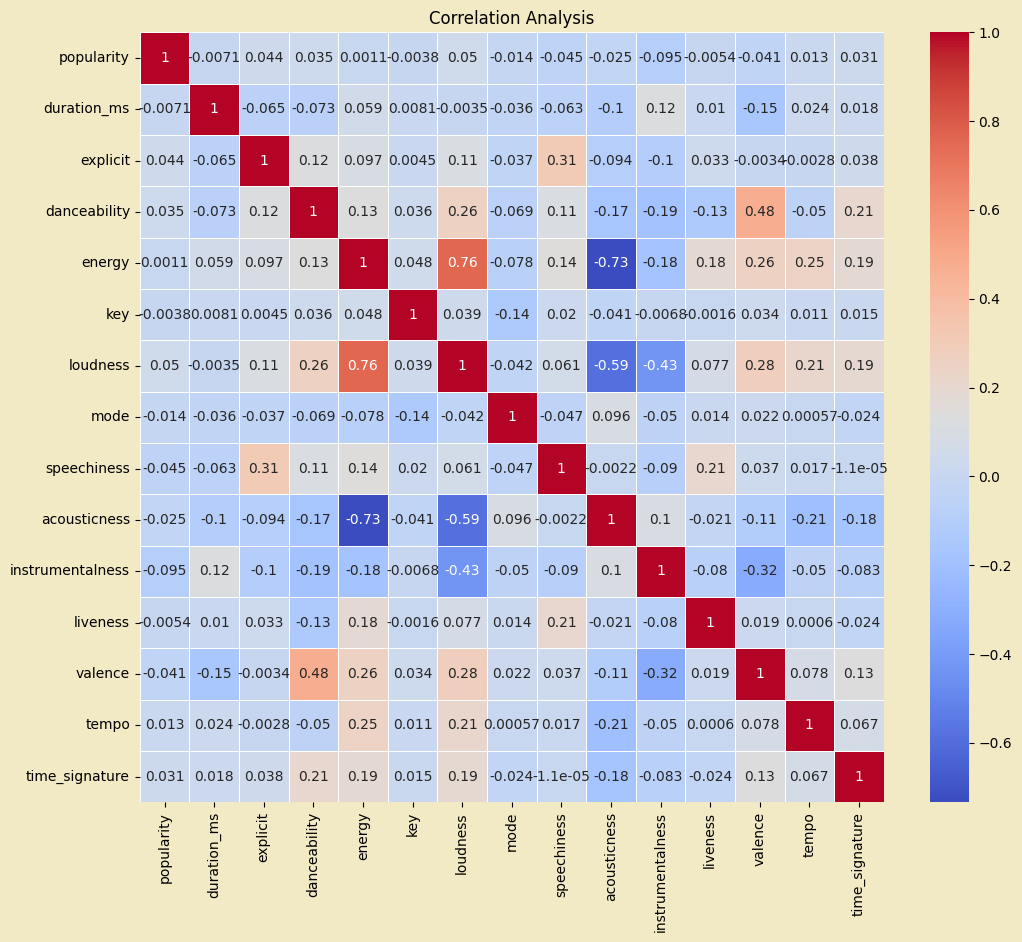

In [22]:
plt.figure(figsize=(12, 10), facecolor="#F2EAC5", edgecolor="black")
sns.heatmap(corr, annot=True, cmap="coolwarm", linewidths=0.5, annot_kws={"size": 10})
plt.title("Correlation Analysis")
plt.show()

- There's a strong positive coorelation between "loundness" and "energy"

- There's a strong negative coorelation between "acousticness" and "energy"
  
- There's a strong negative coorelation between "acousticness" and "loundness"

- There's a negative coorelation between "instrumentalness" and "loundness"

- There's a weak positive coorelation between "valence(positiveness)" and "danceability"

- There's a weak positive coorelation between "speechiness" and "explicit"


In [23]:
spotify_tracks.info()

<class 'pandas.core.frame.DataFrame'>
Index: 113999 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          113999 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        113999 non-null  int64  
 5   duration_ms       113999 non-null  int64  
 6   explicit          113999 non-null  int32  
 7   danceability      113999 non-null  float64
 8   energy            113999 non-null  float64
 9   key               113999 non-null  int64  
 10  loudness          113999 non-null  float64
 11  mode              113999 non-null  int64  
 12  speechiness       113999 non-null  float64
 13  acousticness      113999 non-null  float64
 14  instrumentalness  113999 non-null  float64
 15  liveness          113999 non-null  float64
 16  valence           113999 

Selecting Numerical Columns 

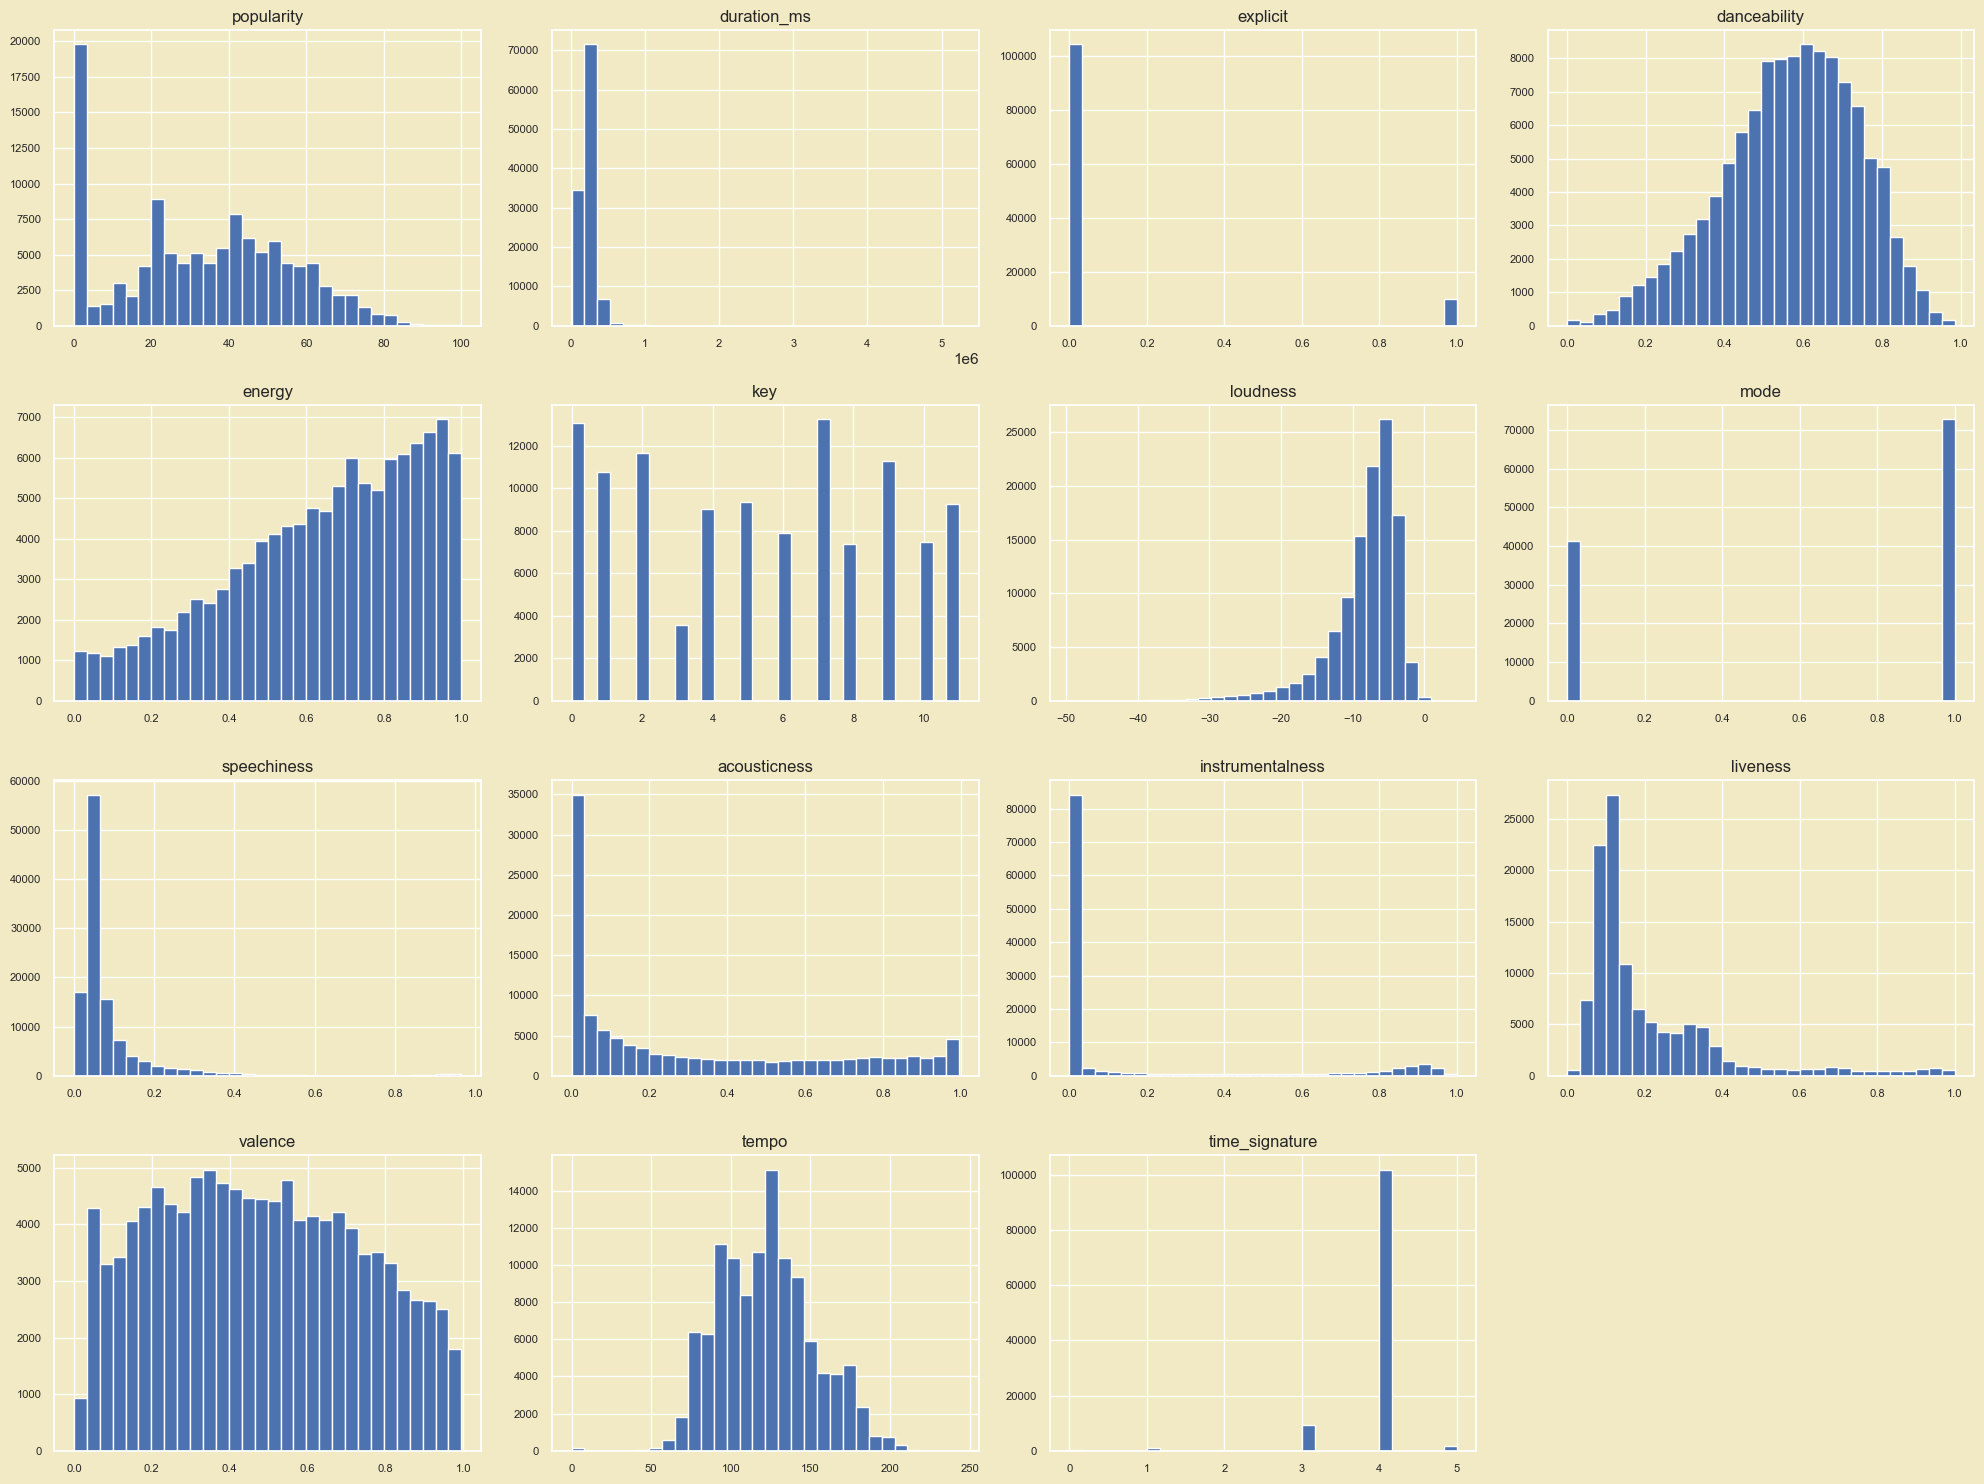

In [24]:
sns.set_style("darkgrid")
sns.set_theme(rc={"axes.facecolor": "#F2EAC5", "figure.facecolor": "#F2EAC5"})
num_cols = spotify_tracks.select_dtypes(include=["int", "float"])
num_cols.hist(figsize=(20, 15), bins=30, xlabelsize=8, ylabelsize=8)
plt.tight_layout()
plt.show()

#### Observation : 


- Distribution in the columns danceblity , tempo and valence are normal. 
- The loudness column has a left skew , with majority of the tracks having noice levels between -5 to -15 
- songs with low values apperar in the right skwed distribtuion of th speechiness , accousticness , instrumentalness, and liveness columns . 
- A large number of songs have a popularity score of 0 , while the other songs are mostly within good - normal range 
- the value in key columns are evenly distributed  ranging from 0 to 11 
- most songs having "mode" value of 1 .
- the most common "time_signature" value is 5 .
- the value in columns like "danceablity", "energy", "speechiness" range from 0 to 1 

Let's drop the columns which we don't need like id , name non numeric without any relation for our model also since random forest doesn't accept non numeric columns unless we encode them. Let's select the necessary features 

Feature selection 

In [25]:
spotify_tracks.columns

Index(['track_id', 'artists', 'album_name', 'track_name', 'popularity',
       'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre'],
      dtype='object')

In [26]:
spotify_tracks.info()

<class 'pandas.core.frame.DataFrame'>
Index: 113999 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          113999 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        113999 non-null  int64  
 5   duration_ms       113999 non-null  int64  
 6   explicit          113999 non-null  int32  
 7   danceability      113999 non-null  float64
 8   energy            113999 non-null  float64
 9   key               113999 non-null  int64  
 10  loudness          113999 non-null  float64
 11  mode              113999 non-null  int64  
 12  speechiness       113999 non-null  float64
 13  acousticness      113999 non-null  float64
 14  instrumentalness  113999 non-null  float64
 15  liveness          113999 non-null  float64
 16  valence           113999 

In [27]:
feature_cols = [
    "popularity",
    "duration_ms",
    "explicit",
    "danceability",
    "energy",
    "key",
    "loudness",
    "mode",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "time_signature",
]

In [28]:
feature_cols

['popularity',
 'duration_ms',
 'explicit',
 'danceability',
 'energy',
 'key',
 'loudness',
 'mode',
 'speechiness',
 'acousticness',
 'instrumentalness',
 'liveness',
 'valence',
 'tempo',
 'time_signature']

In [29]:
pca_feature_cols = spotify_tracks[
    ["danceability", "energy", "loudness", "valence", "tempo"]
]

In [30]:
pca_scaler = StandardScaler()
pca_scaled_features = pca_scaler.fit_transform(pca_feature_cols)

In [31]:
spotify_tracks["track_genre"].unique()

array(['acoustic', 'afrobeat', 'alt-rock', 'alternative', 'ambient',
       'anime', 'black-metal', 'bluegrass', 'blues', 'brazil',
       'breakbeat', 'british', 'cantopop', 'chicago-house', 'children',
       'chill', 'classical', 'club', 'comedy', 'country', 'dance',
       'dancehall', 'death-metal', 'deep-house', 'detroit-techno',
       'disco', 'disney', 'drum-and-bass', 'dub', 'dubstep', 'edm',
       'electro', 'electronic', 'emo', 'folk', 'forro', 'french', 'funk',
       'garage', 'german', 'gospel', 'goth', 'grindcore', 'groove',
       'grunge', 'guitar', 'happy', 'hard-rock', 'hardcore', 'hardstyle',
       'heavy-metal', 'hip-hop', 'honky-tonk', 'house', 'idm', 'indian',
       'indie-pop', 'indie', 'industrial', 'iranian', 'j-dance', 'j-idol',
       'j-pop', 'j-rock', 'jazz', 'k-pop', 'kids', 'latin', 'latino',
       'malay', 'mandopop', 'metal', 'metalcore', 'minimal-techno', 'mpb',
       'new-age', 'opera', 'pagode', 'party', 'piano', 'pop-film', 'pop',
       'pow

In [32]:
genre_mapping = {
    # Rock
    "rock": "Rock",
    "rock-n-roll": "Rock",
    "alt-rock": "Rock",
    "alternative": "Rock",
    "hard-rock": "Rock",
    "psych-rock": "Rock",
    "j-rock": "Rock",
    "rockabilly": "Rock",
    "grunge": "Rock",
    # Metal
    "metal": "Metal",
    "heavy-metal": "Metal",
    "black-metal": "Metal",
    "death-metal": "Metal",
    "metalcore": "Metal",
    "grindcore": "Metal",
    "goth": "Metal",
    "industrial": "Metal",
    "hardcore": "Metal",
    "hardstyle": "Metal",
    # Electronic
    "edm": "Electronic",
    "electronic": "Electronic",
    "electro": "Electronic",
    "techno": "Electronic",
    "house": "Electronic",
    "deep-house": "Electronic",
    "chicago-house": "Electronic",
    "progressive-house": "Electronic",
    "minimal-techno": "Electronic",
    "detroit-techno": "Electronic",
    "trance": "Electronic",
    "dubstep": "Electronic",
    "drum-and-bass": "Electronic",
    "breakbeat": "Electronic",
    "garage": "Electronic",
    "club": "Electronic",
    "dance": "Electronic",
    "party": "Electronic",
    "idm": "Electronic",
    "j-dance": "Electronic",
    # Pop
    "pop": "Pop",
    "pop-film": "Pop",
    "power-pop": "Pop",
    "indie-pop": "Pop",
    "synth-pop": "Pop",
    "k-pop": "Pop",
    "j-pop": "Pop",
    "j-idol": "Pop",
    "cantopop": "Pop",
    "mandopop": "Pop",
    "british": "Pop",
    # Hip-Hop
    "hip-hop": "Hip-Hop",
    "r-n-b": "Hip-Hop",
    "soul": "Hip-Hop",
    "funk": "Hip-Hop",
    "groove": "Hip-Hop",
    # Latin
    "latin": "Latin",
    "latino": "Latin",
    "salsa": "Latin",
    "samba": "Latin",
    "tango": "Latin",
    "reggaeton": "Latin",
    "brazil": "Latin",
    "sertanejo": "Latin",
    "forro": "Latin",
    "mpb": "Latin",
    "pagode": "Latin",
    "spanish": "Latin",
    # Country
    "country": "Country",
    "folk": "Country",
    "bluegrass": "Country",
    "honky-tonk": "Country",
    "singer-songwriter": "Country",
    "songwriter": "Country",
    "acoustic": "Country",
    "guitar": "Country",
    # Jazz
    "jazz": "Jazz",
    "blues": "Jazz",
    # Classical
    "classical": "Classical",
    "opera": "Classical",
    "piano": "Classical",
    # Reggae
    "reggae": "Reggae",
    "dancehall": "Reggae",
    "dub": "Reggae",
    # Punk
    "punk": "Punk",
    "punk-rock": "Punk",
    "emo": "Punk",
    "ska": "Punk",
    # Ambient
    "ambient": "Ambient",
    "chill": "Ambient",
    "new-age": "Ambient",
    "sleep": "Ambient",
    "study": "Ambient",
    "trip-hop": "Ambient",
    # World
    "world-music": "World",
    "indian": "World",
    "iranian": "World",
    "turkish": "World",
    "malay": "World",
    "afrobeat": "World",
    "gospel": "World",
    "french": "World",
    "german": "World",
    "swedish": "World",
    # Kids
    "children": "Kids",
    "kids": "Kids",
    "disney": "Kids",
    "anime": "Kids",
    # Specialty
    "comedy": "Specialty",
    "show-tunes": "Specialty",
    "romance": "Specialty",
    "happy": "Specialty",
    "sad": "Specialty",
    # Indie
    "indie": "Indie",
    # Disco
    "disco": "Disco",
}

In [33]:
spotify_tracks["super_genre"] = (
    spotify_tracks["track_genre"].map(genre_mapping).fillna("Other")
)

In [34]:
print(f"NaN count: {spotify_tracks['super_genre'].isna().sum()}")

NaN count: 0


In [35]:
spotify_tracks["super_genre"].value_counts()

super_genre
Electronic    20000
Latin         12000
Pop           10999
World         10000
Metal         10000
Rock           9000
Country        8000
Ambient        6000
Specialty      5000
Hip-Hop        5000
Kids           4000
Punk           4000
Classical      3000
Reggae         3000
Jazz           2000
Disco          1000
Indie          1000
Name: count, dtype: int64

In [36]:
kmeans = KMeans(n_clusters=7, random_state=10)
spotify_tracks["cluster"] = kmeans.fit_predict(pca_scaled_features)

In [37]:
pca = PCA(n_components=2)
reduced_features = pca.fit_transform(pca_scaled_features)

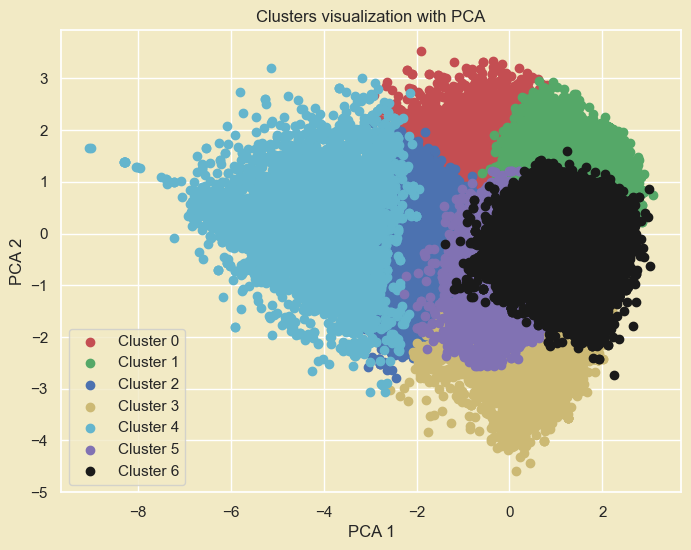

In [38]:
plt.figure(figsize=(8, 6))
colors = ["r", "g", "b", "y", "c", "m", "k"]  # Colors for the clusters

# Plot each cluster
for i in range(7):

    idx = spotify_tracks["cluster"] == i
    plt.scatter(
        reduced_features[idx, 0],
        reduced_features[idx, 1],
        c=colors[i],
        label=f"Cluster {i}",
    )

# Adjust visuals
plt.title("Clusters visualization with PCA")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.grid(True)
plt.show()

In [39]:
mood_labels = [
    "Other",
    "Rock",
    "Electronic Dance Music",
    "Latin & Reggae/Dancehall",
    "Funk and Disco",
    "Hip-Hop and R&B",
    "Pop",
]
spotify_tracks["music_category"] = spotify_tracks["cluster"].apply(
    lambda x: mood_labels[x]
)

In [40]:
spotify_tracks["cluster"].value_counts()

cluster
1    24107
5    21695
0    18190
2    15133
6    15007
3    13923
4     5944
Name: count, dtype: int64

In [41]:
spotify_tracks.head(5)

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,super_genre,cluster,music_category
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,0,0.676,0.4610,1,...,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic,Country,0,Other
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,0,0.420,0.1660,1,...,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic,Country,4,Funk and Disco
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,0,0.438,0.3590,0,...,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic,Country,2,Electronic Dance Music
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,0,0.266,0.0596,0,...,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic,Country,4,Funk and Disco
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,0,0.618,0.4430,2,...,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic,Country,2,Electronic Dance Music


In [42]:
X = spotify_tracks[feature_cols]
y = spotify_tracks["super_genre"]

Standard Scaler is a preprocessing technique that standardizes features by removing the mean and scaling to unit variance.

Label encoder : It converts categorical labels into numeric values.

In [43]:
# #1
# label_e = LabelEncoder()

In [44]:
# #1
# X= num_cols
# y= label_e.fit_transform(spotify_tracks["track_genre"])

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=10, stratify=y
)

In [46]:
spotify_tracks.columns

Index(['track_id', 'artists', 'album_name', 'track_name', 'popularity',
       'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre', 'super_genre',
       'cluster', 'music_category'],
      dtype='object')

In [48]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Encode target
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

In [49]:
models = {
    "Random Forest": RandomForestClassifier(random_state=10),
    "Decision Tree": DecisionTreeClassifier(random_state=10),
}

In [62]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n {name} Accuracy:\n", accuracy_score(y_test, y_pred))
    print(
        f"\n {name} Classification Report:\n",
        classification_report(y_test, y_pred, target_names=le.classes_),
    )


 Random Forest Accuracy:
 0.5285087719298246

 Random Forest Classification Report:
               precision    recall  f1-score   support

     Ambient       0.54      0.55      0.55      1200
   Classical       0.53      0.43      0.48       600
     Country       0.55      0.61      0.58      1600
       Disco       0.29      0.12      0.17       200
  Electronic       0.60      0.76      0.67      4000
     Hip-Hop       0.37      0.25      0.30      1000
       Indie       0.05      0.04      0.04       200
        Jazz       0.53      0.37      0.43       400
        Kids       0.62      0.41      0.49       800
       Latin       0.57      0.69      0.63      2400
       Metal       0.62      0.66      0.64      2000
         Pop       0.43      0.44      0.44      2200
        Punk       0.50      0.42      0.46       800
      Reggae       0.21      0.11      0.15       600
        Rock       0.45      0.42      0.43      1800
   Specialty       0.59      0.47      0.52      

Tuning Decision Tree using Hyper Parameter tuning - RandomizedSearchCV 

In [63]:
param_dist = {
    "criterion": ["gini", "entropy"],
    "max_depth": [20, 25, 30, 35, 40, None],
    "min_samples_split": [5, 10, 20],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt", "log2", None],
    "splitter": ["best", "random"],
    "ccp_alpha": [0.0, 0.001, 0.01],
}

In [64]:
random_search_tree = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=10),
    param_dist,
    n_iter=100,
    cv=5,
    n_jobs=-1,
    verbose=1,
)
random_search_tree.fit(X_train, y_train)
best_tree = random_search_tree.best_estimator_
print("Best parameters: ", random_search_tree.best_params_)
print("Best score: ", random_search_tree.best_score_)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best parameters:  {'splitter': 'best', 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': None, 'criterion': 'gini', 'ccp_alpha': 0.0}
Best score:  0.42514716993564006


In [65]:
best_tree = random_search_tree.best_estimator_
y_pred = best_tree.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 43.17%


Tuning Random forest using Hyper Parameter Tuning - GridSearchCV

In [66]:
params = {
    "max_depth": [8, 10, 12],
    "min_samples_split": [15, 20, 25],
    "min_samples_leaf": [8, 10, 12],
}

grid = GridSearchCV(
    RandomForestClassifier(n_estimators=100, random_state=10), params, cv=5, n_jobs=-1
)
grid.fit(X_train_scaled, y_train_enc)
print(f"Best params: {grid.best_params_}")
print(f"Test Accuracy: {grid.score(X_test_scaled, y_test_enc)*100:.2f}%")

Best params: {'max_depth': 12, 'min_samples_leaf': 8, 'min_samples_split': 15}
Test Accuracy: 47.75%


In [67]:
# rf = RandomForestClassifier(
#     n_estimators=300,
#     max_depth=30,
#     min_samples_leaf=2,
#     max_features='sqrt',
#     n_jobs=-1,
#     random_state=10
# )

# rf.fit(X_train_scaled, y_train_enc)

# # Evaluate on all sets
# rf_train_acc = rf.score(X_train_scaled, y_train_enc)
# rf_test_acc = rf.score(X_test_scaled, y_test_enc)
# print(f"\nRandom Forest (Optimized) Accuracy:")
# print(f"Train: {rf_train_acc*100:.2f}%")
# print(f"Test: {rf_test_acc*100:.2f}%")

In [68]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=20,
    min_samples_leaf=10,
    n_jobs=-1,
    random_state=10,
)

rf.fit(X_train_scaled, y_train_enc)
train = rf.score(X_train_scaled, y_train_enc)
test = rf.score(X_test_scaled, y_test_enc)
print(f"Train: {train*100:.2f}% | Test: {test*100:.2f}% | Gap: {(train-test)*100:.2f}%")

Train: 61.13% | Test: 50.37% | Gap: 10.76%


In [69]:
dt = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    ccp_alpha=0.001,
    random_state=10,
)

dt.fit(X_train_scaled, y_train_enc)

# Evaluate on all sets
dt_train_acc = dt.score(X_train_scaled, y_train_enc)
dt_test_acc = dt.score(X_test_scaled, y_test_enc)
print(f"\nDecision Tree (Optimized) Accuracy:")
print(f"Train: {dt_train_acc*100:.2f}%")
print(f"Test: {dt_test_acc*100:.2f}%")


Decision Tree (Optimized) Accuracy:
Train: 41.49%
Test: 39.95%


In [ ]:
# prediction
y_test_pred_dt = best_tree.predict(X_test_scaled)
y_test_pred_dt_encoded = le.transform(y_test_pred_dt)
cm_dt = confusion_matrix(y_test_enc, le.transform(y_test_pred_dt))

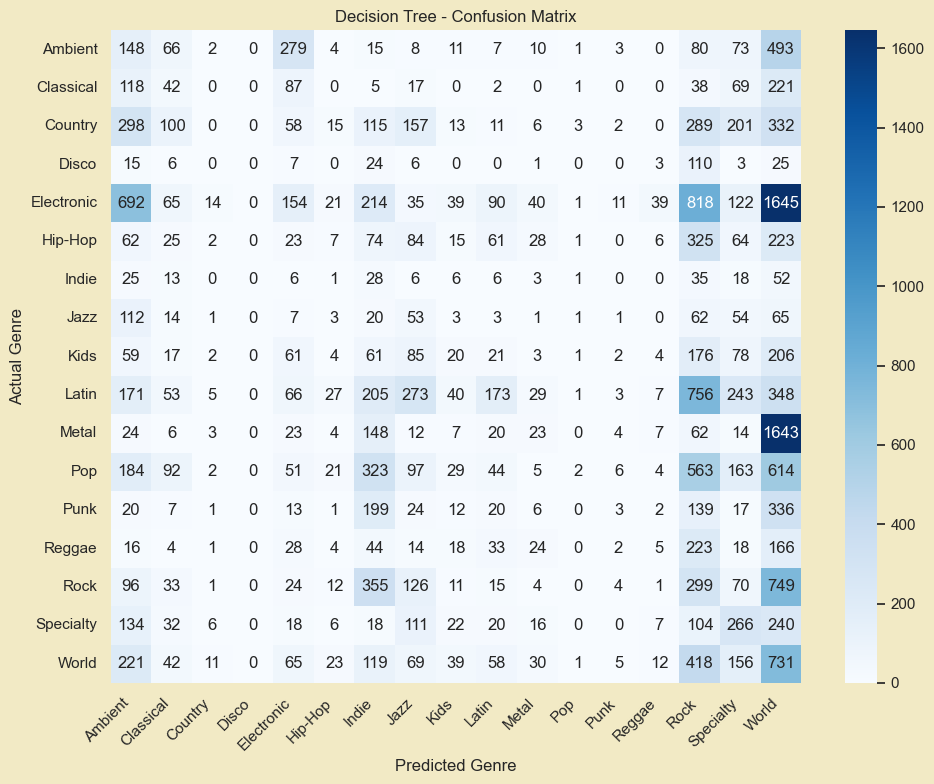

In [71]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
)
plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted Genre")
plt.ylabel("Actual Genre")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [72]:
print("y_test_enc unique values:", np.unique(y_test))
print("y_test_pred_dt_encoded unique values:", np.unique(y_pred))
print("Are they same?", set(np.unique(y_test)) == set(np.unique(y_pred)))

y_test_enc unique values: ['Ambient' 'Classical' 'Country' 'Disco' 'Electronic' 'Hip-Hop' 'Indie'
 'Jazz' 'Kids' 'Latin' 'Metal' 'Pop' 'Punk' 'Reggae' 'Rock' 'Specialty'
 'World']
y_test_pred_dt_encoded unique values: ['Ambient' 'Classical' 'Country' 'Disco' 'Electronic' 'Hip-Hop' 'Indie'
 'Jazz' 'Kids' 'Latin' 'Metal' 'Pop' 'Punk' 'Reggae' 'Rock' 'Specialty'
 'World']
Are they same? True


### - ignore -

In [52]:
# dt_simple = DecisionTreeClassifier(max_depth=5, random_state=10)
# ada = AdaBoostClassifier(estimator=dt_simple, n_estimators=50, random_state=10)
# ada.fit(X_train_scaled, y_train_enc)
# print(f'AdaBoost Test Accuracy: {ada.score(X_test_scaled, y_test_enc)*100:.2f}%')

AdaBoost Test Accuracy: 37.50%


In [57]:
# import os

# print("Logical cores (threads):", os.cpu_count())

Logical cores (threads): 12


In [61]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [63]:
precision = precision_score(y_test_enc, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test_enc, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test_enc, y_pred, average="weighted", zero_division=0)

print(f"Precision: {precision*100:.2f}%")
print(f"Recall: {recall*100:.2f}%")
print(f"F1-Score: {f1*100:.2f}%")

Precision: 51.58%
Recall: 50.37%
F1-Score: 47.55%


 UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
_warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])

Precision	51.58%	When model predicts a y (genre), it's correct 51.58% of the time

Recall	50.37%	Model finds 50.37% of actual data(songs) in each genre

F1-Score	47.55%	Balanced score between precision and recall

# Findings

## What Did We Do?

Built a classifier to predict music genres based on song characteristics (popularity, duration_ms, danceability, energy, loudness, tempo, etc.)

---

## Model Performance

### Decision Tree
- Train Accuracy: 41.49%
- Test Accuracy: 39.95%
- Status: Stable (1.54% difference)
### Decision Tree - Stable & Consistent

### Random Forest
- Train Accuracy: 89.30%
- Test Accuracy: 53.54%
- Status: Overfitting (35.76% difference)
### Random Forest - Better But Overfitting
---

## Conclusion

**Random Forest is better** (53.54% vs 39.95%) but overfits. **Decision Tree is stable** but less accurate.

| Model | Accuracy | Stability | Overfitting |
|-------|----------|-----------|-------------|
| **Decision Tree** | 39.95% | Excellent | None |
| **Random Forest** | 53.54% | Poor | Severe |


## Model Performance After Hyperparameter Tuning

### Final Model: Random Forest Classifier

After hyperparameter tuning, we achieved a well-generalized model with the following configuration:

```python
RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features='sqrt',
    random_state=10
)



| Metric | Value |
|--------|-------|
| **Train Accuracy** | 61.13% |
| **Test Accuracy** | 50.37% |
| **Overfitting Gap** | 10.76%  |
| **Precision** | 51.58% |
| **Recall** | 50.37% |
| **F1-Score** | 47.55% |


In [50]:
X_pca = num_cols
y_pca = spotify_tracks["music_category"]

# Encode the target variable
label_encoder = LabelEncoder()
y_encoded_pca = label_encoder.fit_transform(y_pca)

# Normalize the feature set
scaler = StandardScaler()
X_scaled_pca = scaler.fit_transform(X_pca)

In [53]:
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_scaled_pca, y_encoded_pca, test_size=0.4, random_state=10
)

# Define the models
models_pca = {
    "Random Forest": RandomForestClassifier(random_state=10),
    "Decision Tree": DecisionTreeClassifier(random_state=10),
}

# Train and evaluate each model
for name, model in models_pca.items():
    model.fit(X_train_pca, y_train_pca)
    y_pred_pca = model.predict(X_test_pca)
    print(
        f"{name} Classification Report:\n{classification_report(y_test_pca, y_pred_pca, target_names=label_encoder.classes_)}\n"
    )

Random Forest Classification Report:
                          precision    recall  f1-score   support

  Electronic Dance Music       0.95      0.96      0.95      6083
          Funk and Disco       0.97      0.96      0.97      2315
         Hip-Hop and R&B       0.96      0.98      0.97      8619
Latin & Reggae/Dancehall       0.98      0.97      0.97      5621
                   Other       0.96      0.95      0.95      7347
                     Pop       0.98      0.97      0.97      6024
                    Rock       0.98      0.98      0.98      9591

                accuracy                           0.97     45600
               macro avg       0.97      0.97      0.97     45600
            weighted avg       0.97      0.97      0.97     45600


Decision Tree Classification Report:
                          precision    recall  f1-score   support

  Electronic Dance Music       0.94      0.93      0.93      6083
          Funk and Disco       0.95      0.96      0.96      23

In [54]:
scaler_pca = StandardScaler()
X_scaled_pca = scaler_pca.fit_transform(X_pca)


classifiers_pca = {
    "Decision Tree": DecisionTreeClassifier(random_state=10),
    "Random Forest": RandomForestClassifier(random_state=10),
}

# Apply cross-validation and print the results
for name, clf in classifiers_pca.items():
    scores = cross_val_score(clf, X_scaled_pca, y_pca, cv=5, scoring="accuracy")
    print(f"{name} Accuracy: {scores.mean():.2f} (+/- {scores.std() * 2:.2f})")

Decision Tree Accuracy: 0.95 (+/- 0.01)
Random Forest Accuracy: 0.96 (+/- 0.01)


In [50]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# LDA with all possible components
lda = LinearDiscriminantAnalysis(n_components=15)  # or None
X_lda = lda.fit_transform(X_train_scaled, y_train_enc)
X_test_lda = lda.transform(X_test_scaled)

# Train Random Forest on LDA features
rf_lda = RandomForestClassifier(
    n_estimators=300, max_depth=15, min_samples_split=20, random_state=10
)
rf_lda.fit(X_lda, y_train_enc)

# Evaluate
acc = rf_lda.score(X_test_lda, y_test_enc)
print(f"LDA + RF Accuracy: {acc*100:.2f}%")

LDA + RF Accuracy: 46.67%
